# Michikamau Intrusion ca. 1460 Ma paleomagnetic pole

## Geologic context

The Michikamau Intrusion of central Labrador is a large, weakly to strongly
layered leucotroctolite-anorthosite massif with minor late adamellite, surrounded
by a thermal contact aureole up to several kilometres wide developed in pelitic
rocks of the older Petscapiskau Group (Emslie, Irving & Park, 1976). The intrusion
has not been regionally deformed or metamorphosed since consolidation. A U-Pb
zircon age of ~1460 Ma (Krogh & Davis, 1973) on the youngest adamellite dates
emplacement; the magnetization age is ~1450-1460 Ma. The remanence is carried by
fine-grained, titanium-free magnetite and hematite.

## Pole

This notebook recreates the Michikamau pole at the site level from the 12
collecting localities of Murthy et al. (1968) and Emslie et al. (1976). The
intrusion's westerly, shallow magnetization is shown to be primary by a positive
baked-contact (Bruhnes) test: country rock within the thermal aureole (Emslie's
site 13) carries the intrusion direction, while the older Petscapiskau Group
outside the aureole (site 22) carries a distinct northeast direction.

## Age constraints

- Current bracket: nominal age 1460 Ma, lomagage 1455 Ma, himagage 1465 Ma. 
**- proposed new bracket: nominal age 1469 Ma, lomagage 1468 Ma, himagage 1470 Ma.**
- Michikamau Intrusion includes layered mafic rocks, anorthosite and lesser diorite and syenite (Emslie, 1968). Early investigations of
these rocks suggested a U–Pb age of ca. 1460 Ma (Krogh and Davis, 1973), but Kerr and McNicoll (2010) subsequently obtained an older U–Pb baddeleyite age of 1469 ± 1 Ma from anorthosite. Kerr and McNicoll, 2010 reported a U-Pb baddeleyite ID-TIMS concordia upper intercept age of 1469$\pm$1 Ma for a pegmatitic leuconorite (anorthosite) gradational with mineralized rocks at the Juno zone, Michikamau Intrusion; Let's use the newer 1469 ± 1 Ma for the age of the paleomagnetic records. However this is an intrusive mafic anorthositic unit later intruded by granitic rocks ca. 1430 Ma. We do not have enough data to assess the cooling ages (magnetization acquisition age) of the rocks.

## References

### Paleomagnetism
- Emslie, R. F., Irving, E., & Park, J. K. (1976). Further paleomagnetic results from the Michikamau intrusion, labrador. Canadian Journal of Earth Sciences, 13(8), 1052–1057. https://doi.org/10.1139/e76-108

### Geochronology

- Kerr, A., & McNicoll, V. (2010). U–Pb ages from mafic rocks associated with orthomagmatic Ni–Cu–Co sulphide mineralization in west-central Labrador (Report 10-1, pp. 23–39). Newfoundland and Labrador Department of Natural Resources, Geological Survey.
- Krogh, T. E., & Davis, G. L. (1973). The significance of inherited zircons on the age and origin of igneous rocks—an investigation of the ages of the Labrador adamellites. Carnegie Institute of Washington Yearbook, 72(1630), 610-613.
- Kerr, A., & Hamilton, M. (2014). Rare-earth element (REE) mineralization in the Mistastin Lake and Smallwood Reservoir areas, Labrador: Field relationships and preliminary U–Pb zircon ages from host granitoid rocks. Current Research. Government of Newfoundland and Labrador, Department of Natural Resources, Geological Survey, Report, 1, 45–63.


In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Loaded from `../data/1460_Michikamau/`. The pole uses the 12 Michikamau Intrusion
localities; the Petscapiskau Group meta-andesite (the baked-contact reference
outside the aureole) is held separately. Directions are in-situ (intrusive rocks).

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1460_Michikamau/sites.txt')
michikamau = sites_geo[sites_geo['location'] == 'Michikamau Intrusion'].reset_index(drop=True)
petscapiskau = sites_geo[sites_geo['location'].str.contains('Petscapiskau', na=False)].reset_index(drop=True)
study_lat, study_lon = 54.5, 296.0
print(f'{len(michikamau)} Michikamau localities; {len(petscapiskau)} Petscapiskau reference')
michikamau[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_alpha95', 'dir_k',
            'dir_n_samples', 'vgp_lat', 'vgp_lon']]

12 Michikamau localities; 1 Petscapiskau reference


,site,lat,lon,dir_dec,dir_inc,dir_alpha95,dir_k,dir_n_samples,vgp_lat,vgp_lon
0,1,54.413886,296.272720,249.0,16.0,3.83,400.000,5,-5.2,228.2
1,2,54.408381,296.254329,255.0,19.0,7.69,100.000,5,-0.6,224.1
2,3,54.293155,295.982937,262.0,-1.0,25.19,25.000,3,-5.1,212.2
3,4,54.280096,295.927965,253.0,3.0,33.90,14.286,3,-8.6,220.7
4,5,54.346740,295.943154,261.0,25.0,17.05,30.000,4,5.5,220.9
5,6,54.374518,296.302665,262.0,13.0,19.72,16.000,5,0.7,216.6
6,7,54.281400,296.273000,256.0,18.5,6.00,91.100,6,-0.3,223.1
7,8,54.372700,295.927000,262.5,6.5,16.00,15.300,5,-1.7,213.9
8,9,54.570000,296.108000,259.5,22.5,26.00,5.750,5,3.5,221.4
9,10,54.520000,296.023000,267.5,-2.5,14.00,25.600,4,-2.5,207.3


## Mean pole from site VGPs

The intrusion carries a single westerly, shallow magnetization; the Fisher mean
of the 12 locality VGPs gives the pole.

Plon: 217.8  Plat: -1.4
Number of directions in mean (n): 12
Angular radius of 95% confidence (A_95): 4.3
Precision parameter (k) estimate: 103.6

Emslie et al. (1976): pole 1.5 S / 142 W (= -1.5 N, 218 E), A95 4.5, N=12
prior compilation (GPMDB 2274): -1.5 N / 217.5 E, A95 4.7


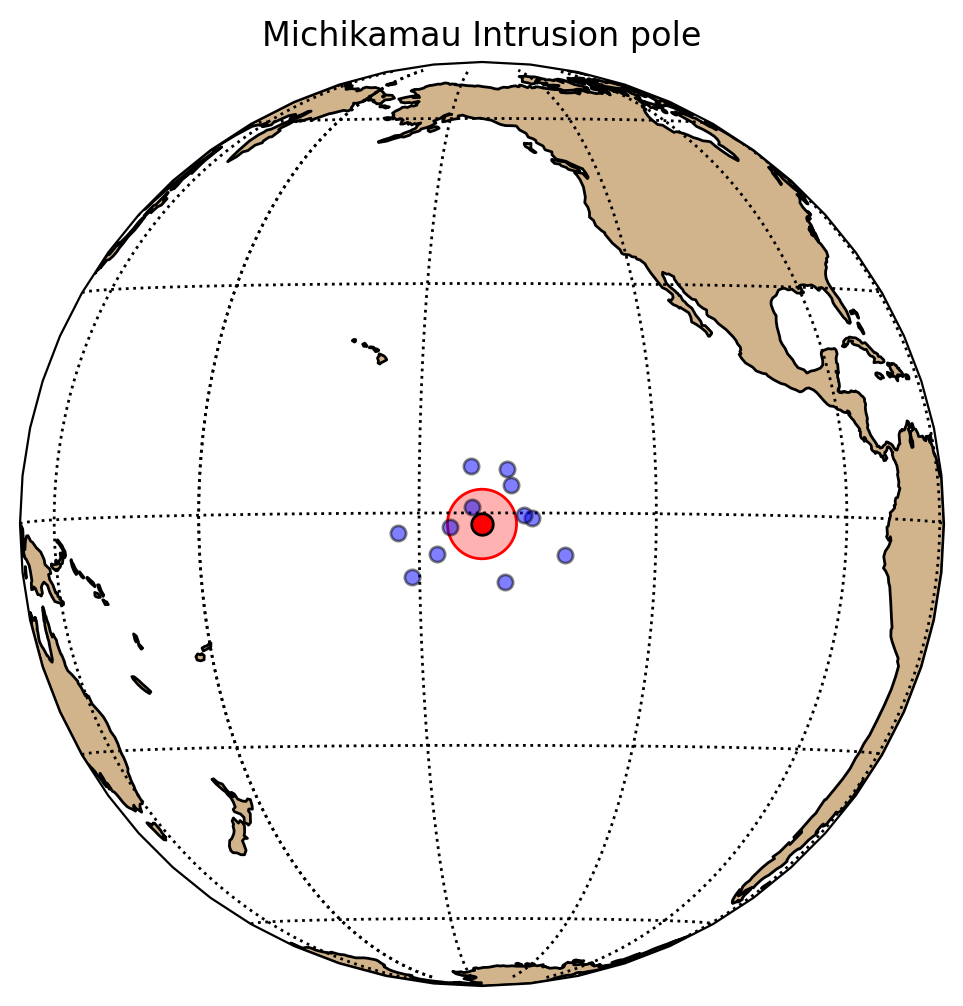

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(michikamau, unify_polarity=False)
ipmag.print_pole_mean(pole_mean)
print('\nEmslie et al. (1976): pole 1.5 S / 142 W (= -1.5 N, 218 E), A95 4.5, N=12')
print('prior compilation (GPMDB 2274): -1.5 N / 217.5 E, A95 4.7')
_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Michikamau Intrusion pole')
plt.show()

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(michikamau, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)

Dec: 259.6  Inc: 11.1
Number of directions in mean (n): 12
Angular radius of 95% confidence (a_95): 6.7
Precision parameter (k) estimate: 43.0


## Field test: baked contact (Bruhnes test)

The country rock within the thermal aureole (Emslie's site 13) carries the
westerly intrusion direction, whereas the older Petscapiskau Group meta-andesite
outside the aureole (site 22) carries a distinct northeast-and-up direction — a
positive baked-contact test indicating the intrusion's magnetization is primary
(acquired on cooling). The intrusion mean and the Petscapiskau reference
direction are compared below.

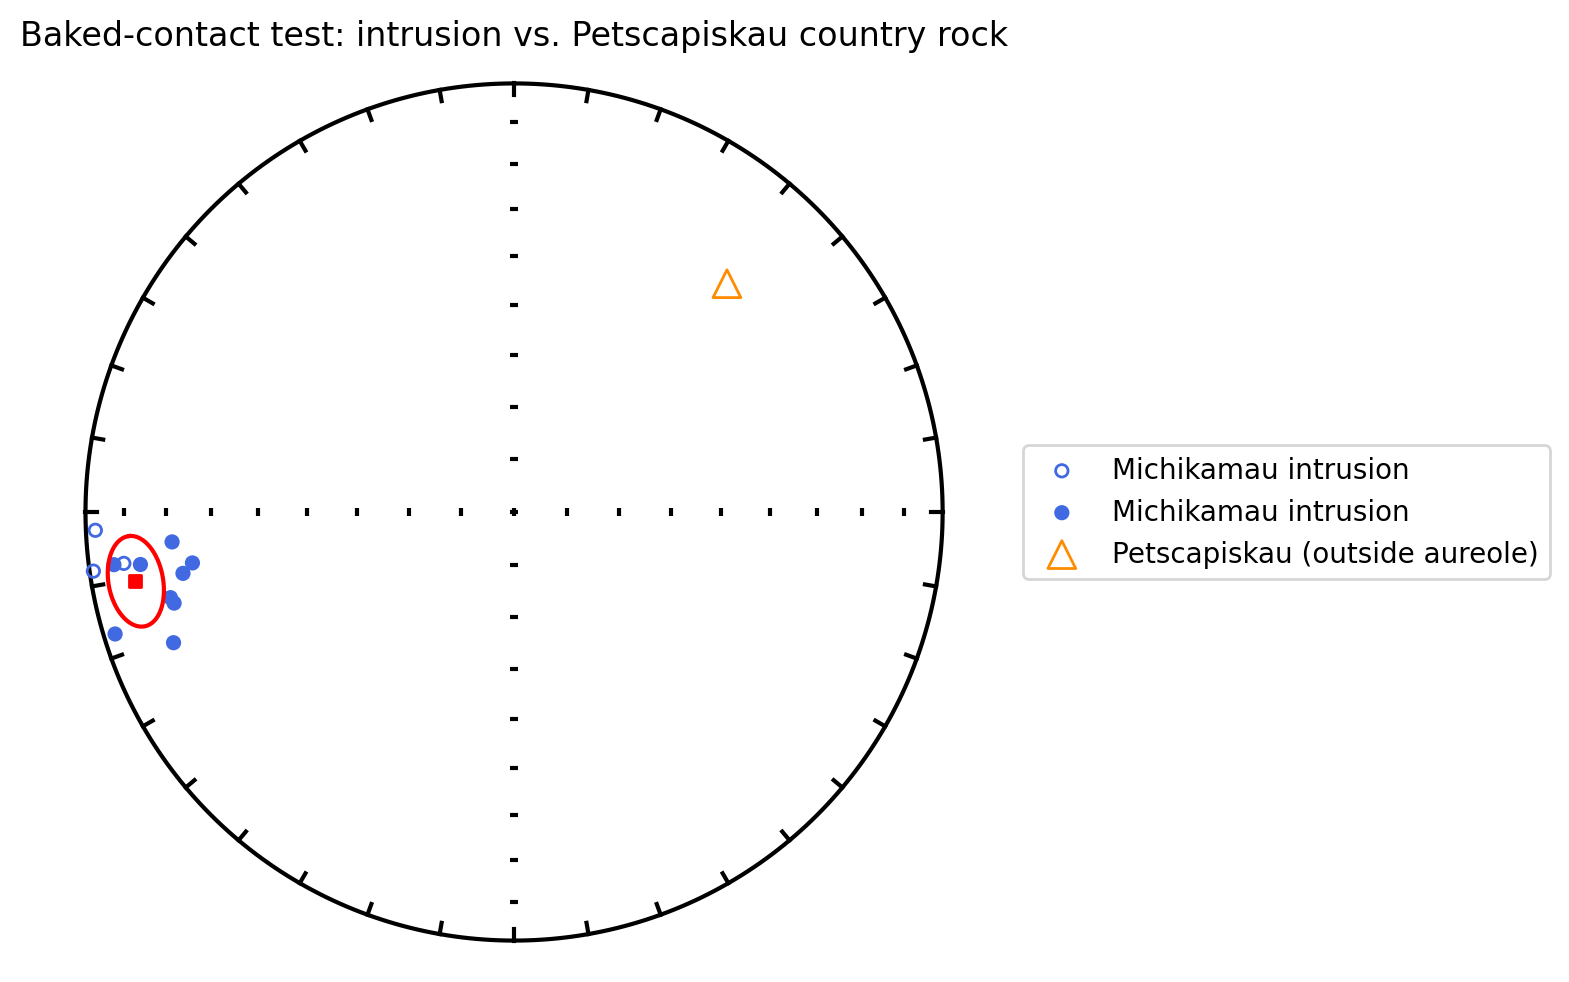

In [5]:
ipmag.plot_net()
ipmag.plot_di(michikamau['dir_dec'].tolist(), michikamau['dir_inc'].tolist(),
              color='royalblue', marker='o', label='Michikamau intrusion')
if len(petscapiskau):
    ipmag.plot_di(petscapiskau['dir_dec'].tolist(), petscapiskau['dir_inc'].tolist(),
                  color='darkorange', marker='^', markersize=100,
                  label='Petscapiskau (outside aureole)')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Baked-contact test: intrusion vs. Petscapiskau country rock')
plt.show()

## Paleosecular variation and VGP-shape diagnostics

The anorthosite VGPs are tightly clustered (K ≫ 70), so the Deenen et al. (2011)
test flags possible under-sampling of paleosecular variation, consistent with the
prior compilation scoring R2 = 0.

A_95 of 4.3 is too small for Deenen criteria of 4.4 for this number of sites


<Axes: title={'center': 'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

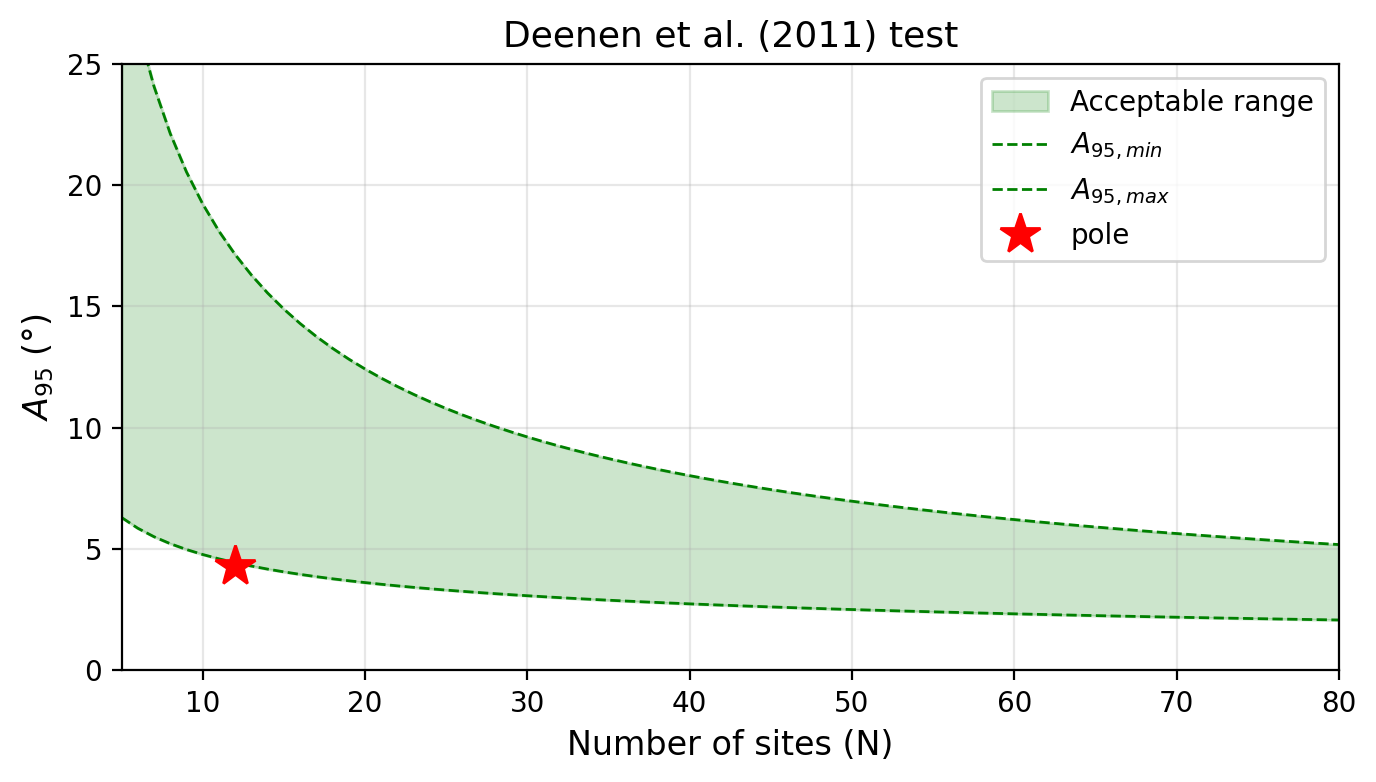

In [6]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

{'Mode': 'Mode 2',
 'Dec': np.float64(-142.16388420068313),
 'Inc': np.float64(-1.36199830345819),
 'N': 12,
 'Mu': np.float64(0.806521558900417),
 'Mu_critical': 1.207,
 'Me': np.float64(1.025738600356869),
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

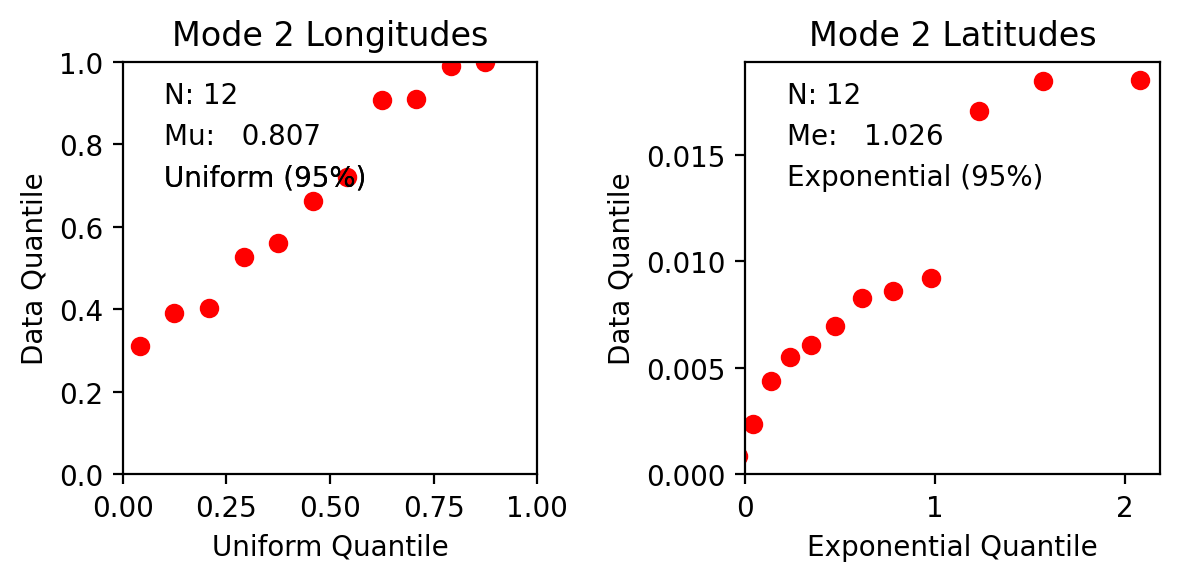

In [7]:
fishqq_result = pt.fishqq_vgps(michikamau, unify_polarity=False)
fishqq_result

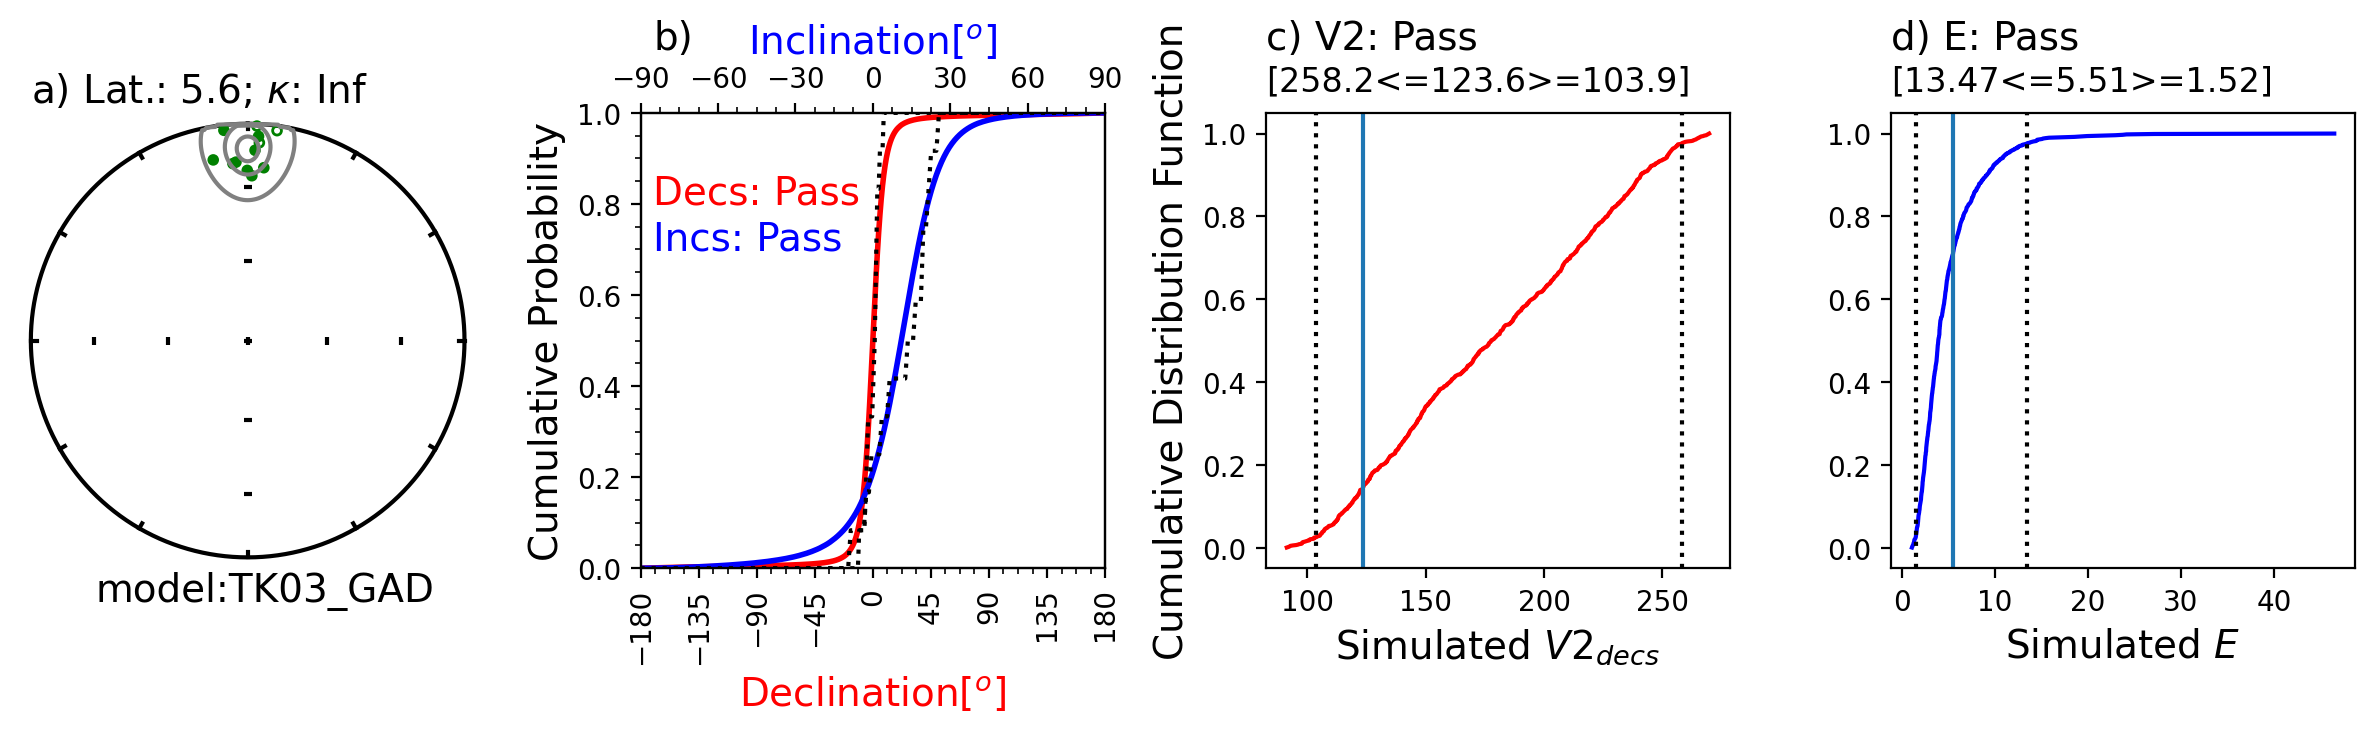

paleolatitude = 5.6 deg; elongation E = 5.51 (consistent with TK03.GAD)


In [8]:
try:
    svei_result = pt.svei_test_vgps(michikamau, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:
    svei_result = pt.svei_test_vgps(michikamau, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Michikamau pole in the context of the Laurentia APWP

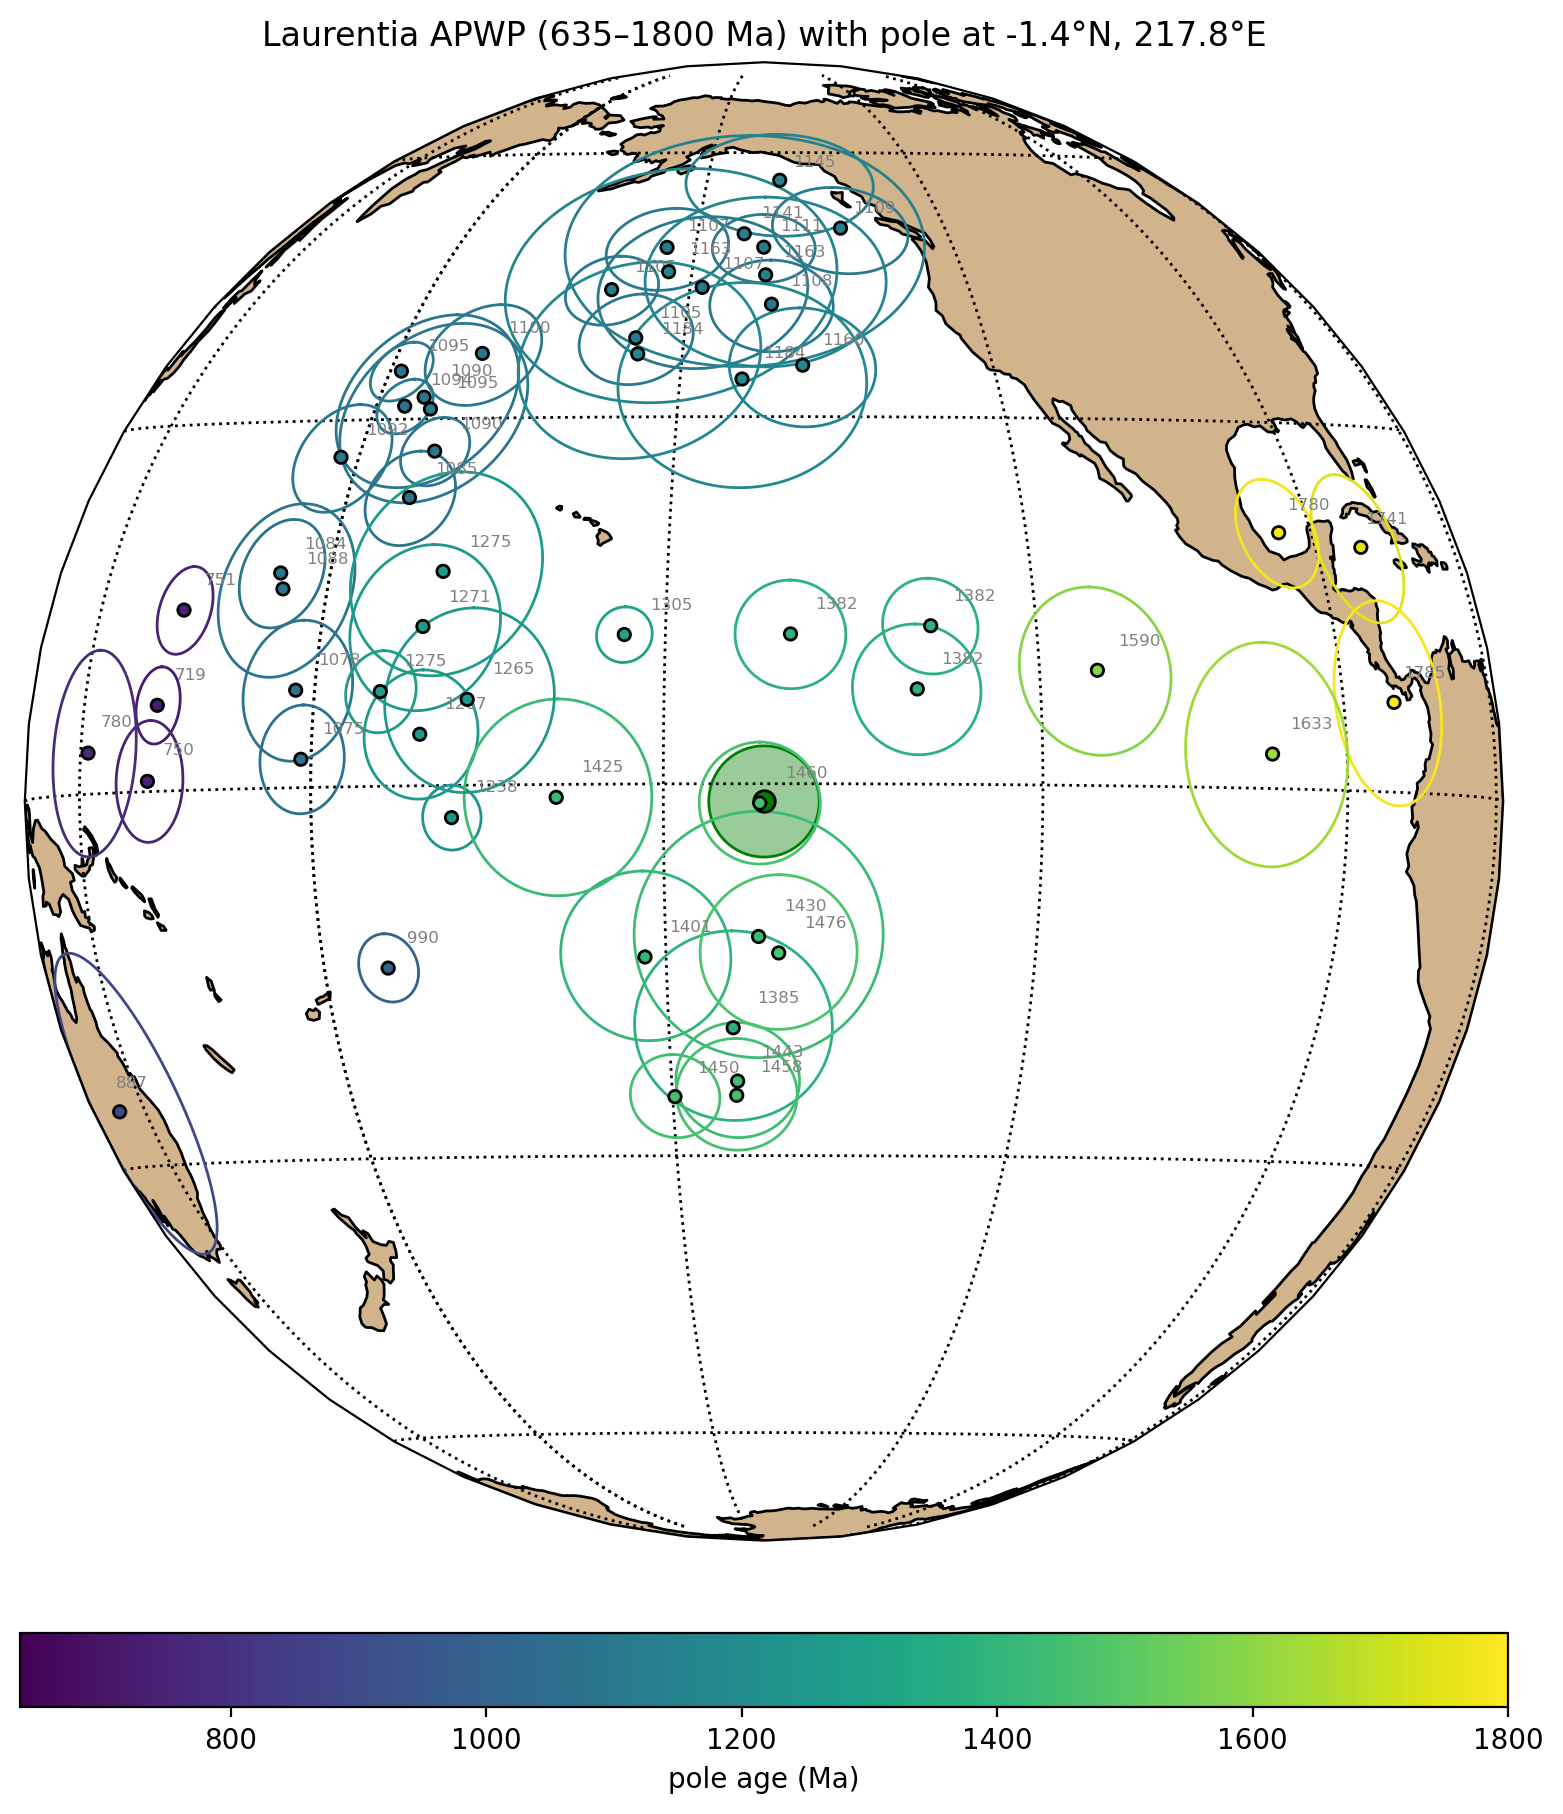

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

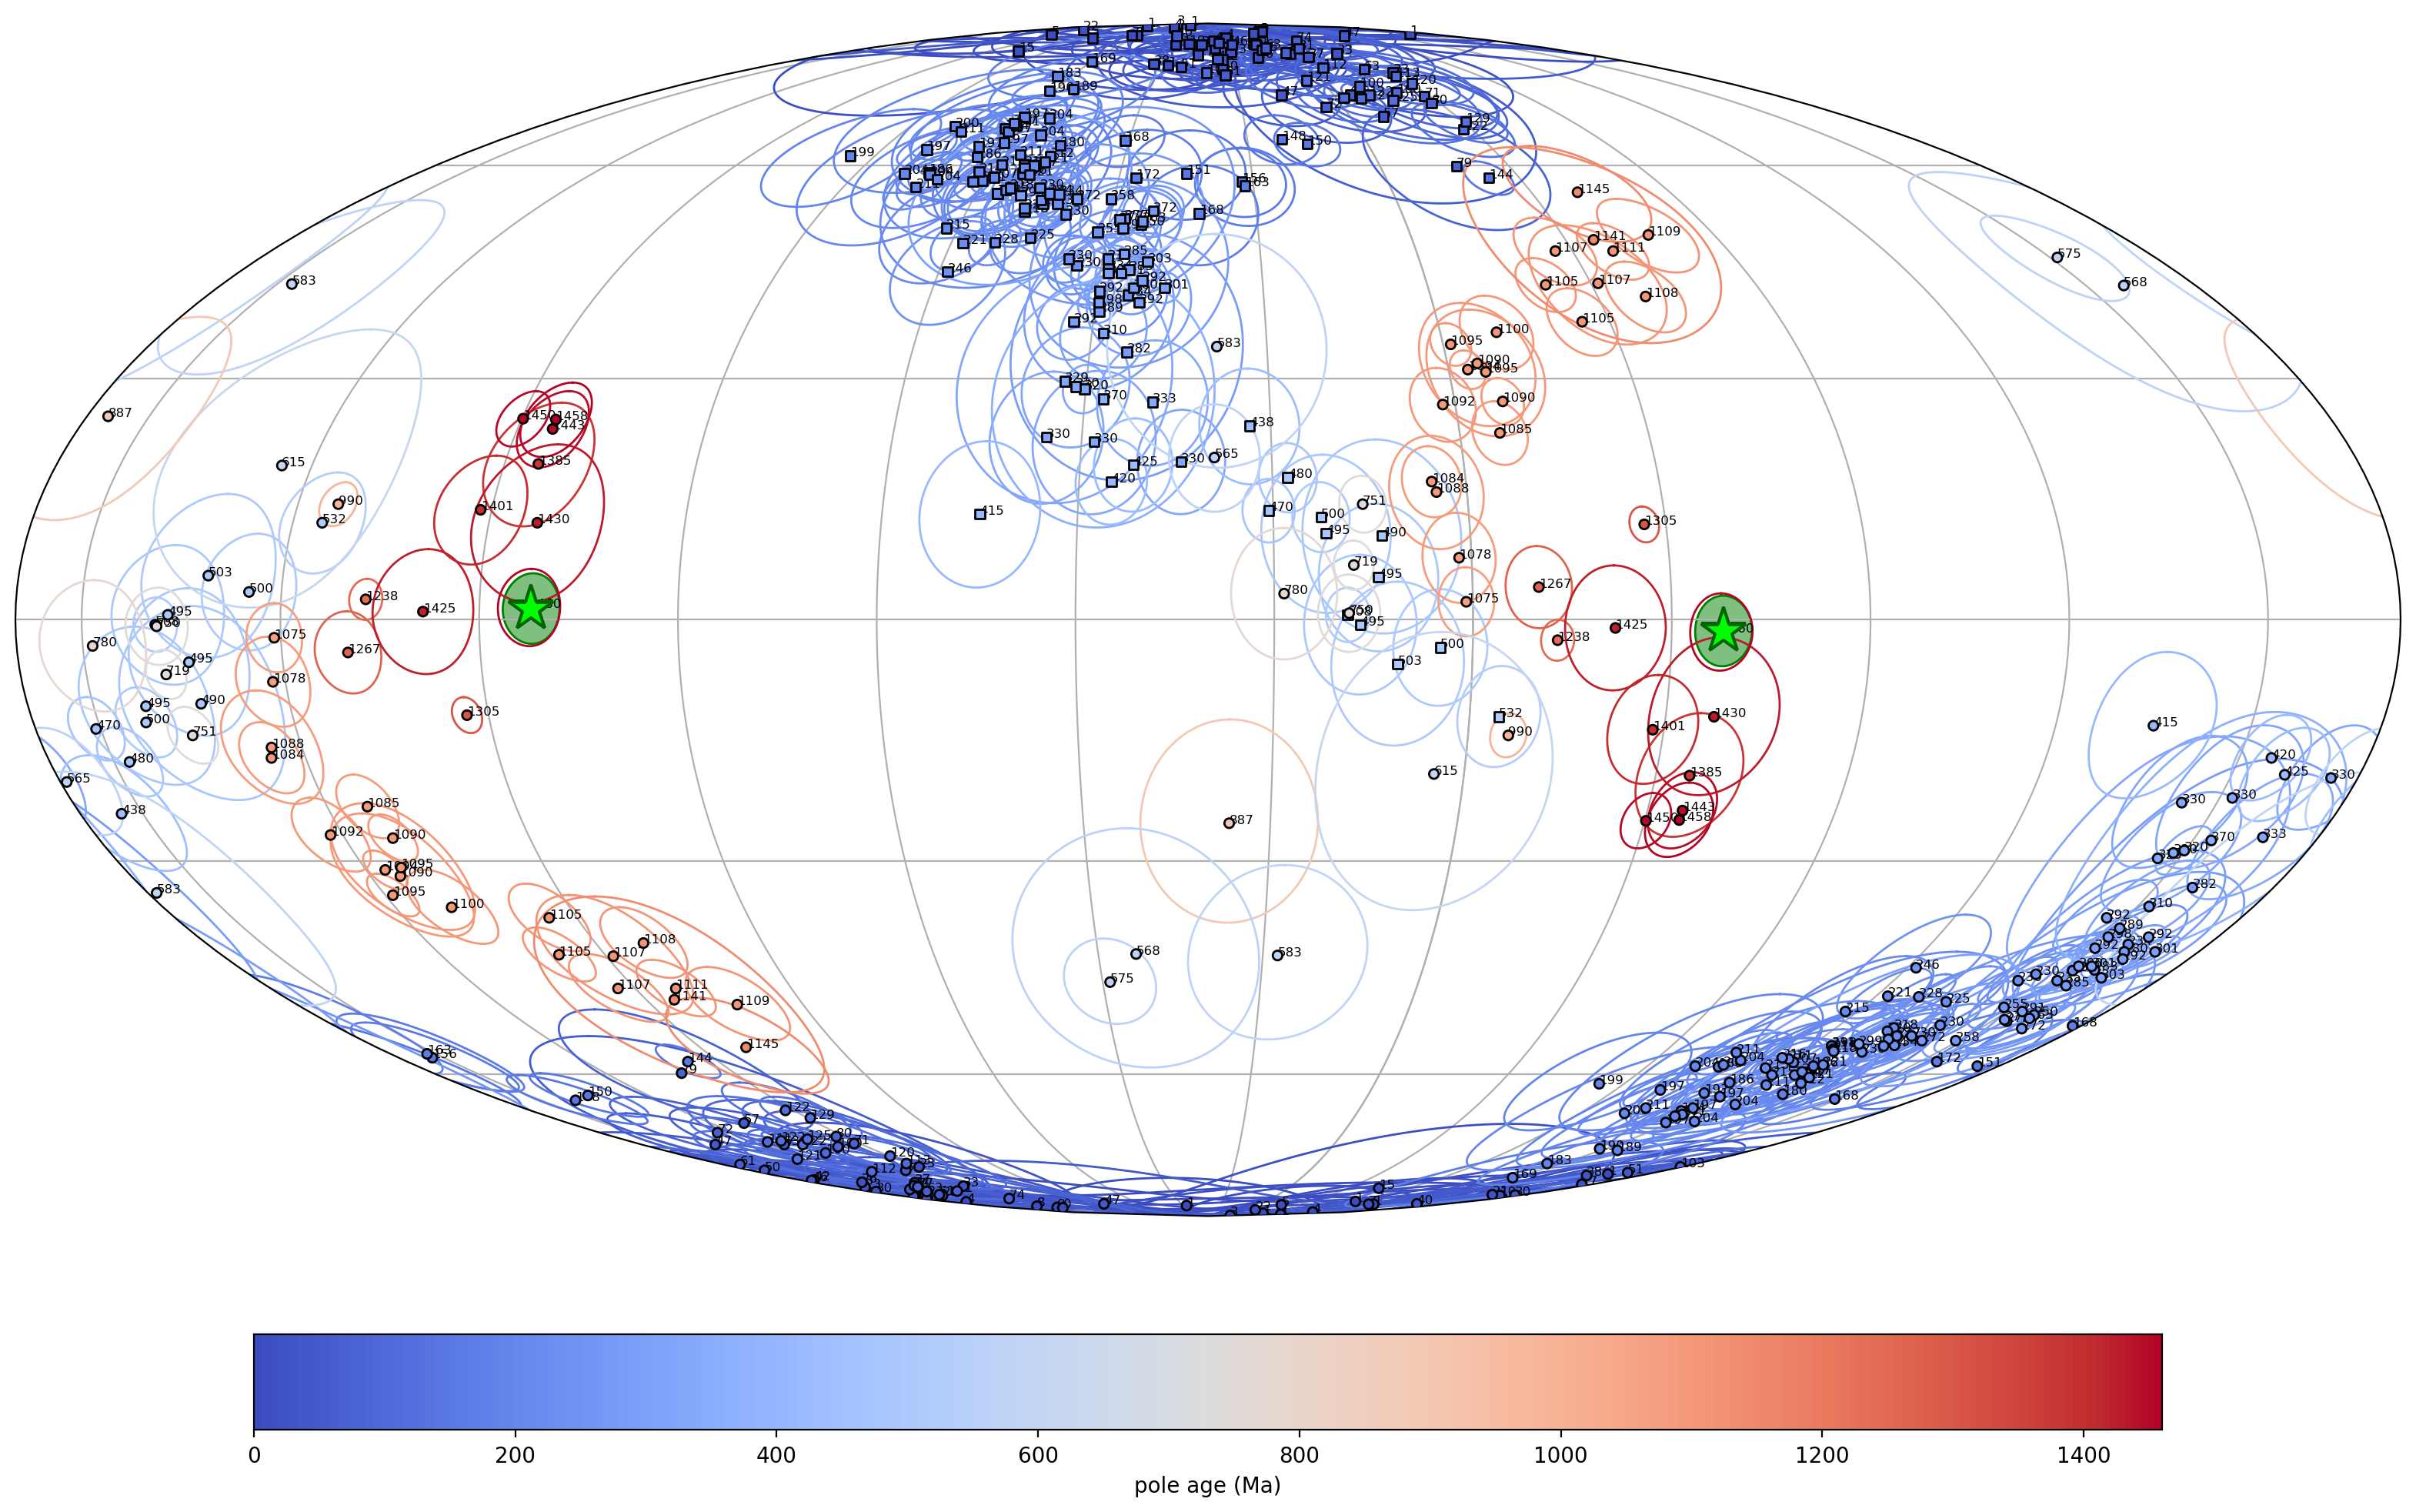

<GeoAxes: >

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Michikamau Intrusion Combined', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1460)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb zircon ~1460 Ma on the youngest adamellite (Krogh & Davis, 1973); magnetization age ~1450-1460 Ma. |
| 2 | Techniques and statistical analysis | **0** | AF + thermal demagnetization with stable end points; however the VGPs are over-concentrated (K ≈ 104 ≫ 70, A95 below the Deenen et al. (2011) lower bound), indicating paleosecular variation is probably under-averaged. |
| 3 | Magnetic mineralogy characterized | **1** | Titanium-free magnetite and hematite identified by thermal/AF demagnetization and polished-section study (Emslie et al., 1976; Murthy et al., 1970). |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact (Bruhnes) test: country rock within the aureole (site 13) carries the intrusion direction, the Petscapiskau Group outside (site 22) differs. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Labrador craton, north of the Grenville Front; not regionally deformed since consolidation. |
| 6 | Presence of reversals | **0** | The 12 localities are of a single (westerly) polarity. A reversed (easterly) hematite component appears within some specimens antiparallel to the magnetite, but there are no reversed site means, so no site-level reversal test applies. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles; baked-contact test independently brackets the age. |
| | Total | **5/7** | Grade A |

## Nordic workshop summary

The Michikamau pole is recreated at the site level from the 12 localities of
Murthy et al. (1968) + Emslie et al. (1976). The recreation reproduces the prior
compilation pole (−1.5°N/217.5°E, GPMDB 2274) and Emslie's published pole
(1.5°S/142°W, A95 4.5). The positive baked-contact test scores R4 = C.

**Note (flag for review):** the prior compilation scored R6 = 1, but the 12
localities are single (westerly) polarity — the reversal is only a within-specimen
magnetite(normal)/hematite(reversed) antiparallelism, not a site-level reversal —
so R6 is scored 0 here (R total 6 → 5; Grade A unchanged).

## Pole comparison

### Characteristic remanent magnetization pole

| | This study (site VGPs) | Emslie et al. (1976) | Previous Nordic compilation |
|---|---|---|---|
| Component | westerly, shallow ChRM | westerly, shallow ChRM | Combined Result |
| N (sites) | 12 | 12 | 12 |
| N (specimens) | 54 | 54 | 54 |
| Dec (°) | 259.6 | 259.5 | 259.5 |
| Inc (°) | 11.1 | 11 | 11.0 |
| k (direction) | 43.0 | 43 | 43.0 |
| α95 (direction, °) | 6.7 | 6.4 | 6.5 |
| Pole lat (°N) | -1.4 | -1.5 | -1.5 |
| Pole lon (°E) | 217.8 | 218 | 217.5 |
| A95, pole (°) | 4.3 | 4.5 | 4.7 |
| dp / dm (°) | — | — | 3.3 / 6.6 |


In [11]:
michikamau_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Michikamau Intrusion Combined',
    sites=michikamau,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='',
    tests='C+ (positive baked-contact / Bruhnes test: aureole country rock matches the intrusion, the older Petscapiskau Group outside the aureole differs)',
    gpmdb_number='2274',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=0, R3=1, R4='C', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1469, lomagage=1468, himagage=1470,
    REF_method="- Current bracket: nominal age 1460 Ma, lomagage 1455 Ma, himagage 1465 Ma. \n**- proposed new bracket: nominal age 1469 Ma, lomagage 1468 Ma, himagage 1470 Ma.**\n- Michikamau Intrusion includes layered mafic rocks, anorthosite and lesser diorite and syenite (Emslie, 1968). Early investigations of\nthese rocks suggested a U–Pb age of ca. 1460 Ma (Krogh and Davis, 1973), but Kerr and McNicoll (2010) subsequently obtained an older U–Pb baddeleyite age of 1469 ± 1 Ma from anorthosite. Kerr and McNicoll, 2010 reported a U-Pb baddeleyite ID-TIMS concordia upper intercept age of 1469$\\pm$1 Ma for a pegmatitic leuconorite (anorthosite) gradational with mineralized rocks at the Juno zone, Michikamau Intrusion; Let's use the newer 1469 ± 1 Ma for the age of the paleomagnetic records. However this is an intrusive mafic anorthositic unit later intruded by granitic rocks ca. 1430 Ma. We do not have enough data to assess the cooling ages (magnetization acquisition age) of the rocks.",
    POLE_AUTHORS='Emslie, R. F., Irving, E., & Park, J. K.; Murthy, G. S., Fahrig, W. F., & Jones, D. L.',
    YEAR=1976,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='13',
    VPAGES='1052-1057',
    TITLE='Further paleomagnetic results from the Michikamau Intrusion, Labrador',
    COMMENT="Mean pole calculation from VGPs as documented in Swanson-Hysell et al. 2026" 
)
pt.save_nordic_summary(michikamau_summary, '1460_Michikamau')
michikamau_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Michikamau Intrusion Combined,GPMDB:2274,"Primary westerly, shallow characteristic reman...",C+ (positive baked-contact / Bruhnes test: aur...,0,54.5,296.0,12,54,...,1470,"- Current bracket: nominal age 1460 Ma, lomaga...",Michikamau Intrusion Combined,"Emslie, R. F., Irving, E., & Park, J. K.; Murt...",1976,Canadian Journal of Earth Sciences,13,1052-1057,Further paleomagnetic results from the Michika...,Mean pole calculation from VGPs as documented ...
